# Modelo 1: SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous inputs)
**Fase CRISP-DM:** Modeling  

## Descripción
SARIMAX es la versión multivariable/exógena de SARIMA. Modela una serie temporal endógena 
(intensidad de tráfico) incorporando variables exógenas (hora, día de la semana, festivos).  
Se entrena un modelo independiente por cada sensor × variable endógena objetivo (intensidad).

## Horizontes de predicción
- **1h** → benchmark de corto plazo  
- **24h** → predicción diaria  
- **168h** → predicción semanal  

## Métricas
- **RMSE** (Root Mean Squared Error) en veh/h  
- **R²** (coeficiente de determinación)

## Paso 1: Carga de datos y configuración del entorno

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Carga de los tres splits cronológicos
# ---------------------------------------------------------------------------
train_df = pd.read_csv('../../data/processed/Split_Datasets/data_train.csv')
val_df   = pd.read_csv('../../data/processed/Split_Datasets/data_val.csv')
test_df  = pd.read_csv('../../data/processed/Split_Datasets/data_test.csv')

def preparar_indice_temporal(df):
    """Convierte 'fecha' en índice datetime con frecuencia horaria estricta."""
    df['fecha'] = pd.to_datetime(df['fecha'])
    df.set_index('fecha', inplace=True)
    df.sort_index(inplace=True)
    df = df.asfreq('h')
    return df

train_df = preparar_indice_temporal(train_df)
val_df   = preparar_indice_temporal(val_df)
test_df  = preparar_indice_temporal(test_df)

# ---------------------------------------------------------------------------
# Definición de columnas endógenas y exógenas
# ---------------------------------------------------------------------------
cols_endogenas = [col for col in train_df.columns
                  if 'intensidad' in col or 'ocupacion' in col or 'vmed' in col]

cols_exogenas  = ['hora', 'dia_semana', 'mes', 'es_finde']

# Sólo las columnas de intensidad serán el objetivo principal de evaluación
cols_intensidad = [col for col in cols_endogenas if 'intensidad' in col]

print("--- ESTRUCTURA DE DATOS ---")
print(f"Train : {train_df.shape} | {train_df.index.min()} → {train_df.index.max()}")
print(f"Val   : {val_df.shape}   | {val_df.index.min()} → {val_df.index.max()}")
print(f"Test  : {test_df.shape}  | {test_df.index.min()} → {test_df.index.max()}")
print(f"\nVariables endógenas ({len(cols_endogenas)}): {cols_endogenas}")
print(f"Variables exógenas  ({len(cols_exogenas)}):  {cols_exogenas}")
print(f"Variables objetivo  ({len(cols_intensidad)}): {cols_intensidad}")

--- ESTRUCTURA DE DATOS ---
Train : (16080, 16) | 2024-01-01 00:00:00 → 2025-10-31 23:00:00
Val   : (1464, 16)   | 2025-11-01 00:00:00 → 2025-12-31 23:00:00
Test  : (1416, 16)  | 2026-01-01 00:00:00 → 2026-02-28 23:00:00

Variables endógenas (12): ['intensidad_3820', 'intensidad_6642', 'intensidad_6676', 'intensidad_6782', 'ocupacion_3820', 'ocupacion_6642', 'ocupacion_6676', 'ocupacion_6782', 'vmed_3820', 'vmed_6642', 'vmed_6676', 'vmed_6782']
Variables exógenas  (4):  ['hora', 'dia_semana', 'mes', 'es_finde']
Variables objetivo  (4): ['intensidad_3820', 'intensidad_6642', 'intensidad_6676', 'intensidad_6782']


C:\Users\Sena\AppData\Local\Temp\ipykernel_9096\3661051354.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## Paso 1.1: Imputación de valores nulos

In [2]:
def limpiar_nulos(df, cols_endo):
    """Imputa nulos por interpolación lineal y reconstruye variables de calendario."""
    df[cols_endo] = df[cols_endo].interpolate(method='linear', limit_direction='both')
    df['hora']       = df.index.hour
    df['dia_semana'] = df.index.dayofweek
    df['mes']        = df.index.month
    df['es_finde']   = (df['dia_semana'] >= 5).astype(int)
    return df

train_df = limpiar_nulos(train_df, cols_endogenas)
val_df   = limpiar_nulos(val_df,   cols_endogenas)
test_df  = limpiar_nulos(test_df,  cols_endogenas)

nulos_total = (train_df.isnull().sum().sum() +
               val_df.isnull().sum().sum()   +
               test_df.isnull().sum().sum())

if nulos_total == 0:
    print("✅ Imputación completada: 0 valores nulos en todos los datasets.")
else:
    print(f"⚠️  Quedan {nulos_total} nulos tras la imputación.")

✅ Imputación completada: 0 valores nulos en todos los datasets.


## Paso 2: Test de estacionariedad (ADF)
Antes de ajustar SARIMAX es necesario comprobar si las series son estacionarias.  
Si **p-valor < 0.05** → la serie ES estacionaria (d=0).  
Si **p-valor ≥ 0.05** → hay raíz unitaria → aplicar diferenciación (d=1).

In [3]:
from statsmodels.tsa.stattools import adfuller

def test_adf(df, columnas):
    """Test de Dickey-Fuller Aumentado para cada columna."""
    print("--- TEST ADF (Dickey-Fuller Aumentado) ---")
    print("H0: La serie NO es estacionaria | H1: La serie ES estacionaria (p < 0.05)\n")
    no_estacionarias = []
    for col in columnas:
        resultado = adfuller(df[col].dropna(), autolag='AIC')
        p = resultado[1]
        estado = "✅ Estacionaria" if p < 0.05 else "❌ No estacionaria"
        if p >= 0.05:
            no_estacionarias.append(col)
        print(f"  {col:<30} p-valor: {p:.4f}  →  {estado}")
    print(f"\nResumen: {len(no_estacionarias)} series no estacionarias de {len(columnas)}")
    return no_estacionarias

series_no_estacionarias = test_adf(train_df, cols_intensidad)

--- TEST ADF (Dickey-Fuller Aumentado) ---
H0: La serie NO es estacionaria | H1: La serie ES estacionaria (p < 0.05)

  intensidad_3820                p-valor: 0.0000  →  ✅ Estacionaria
  intensidad_6642                p-valor: 0.0000  →  ✅ Estacionaria
  intensidad_6676                p-valor: 0.0000  →  ✅ Estacionaria
  intensidad_6782                p-valor: 0.0000  →  ✅ Estacionaria

Resumen: 0 series no estacionarias de 4


## Paso 3: Entrenamiento SARIMAX por sensor
Se entrena un modelo SARIMAX independiente para **cada sensor de intensidad**.  

**Parámetros iniciales (orden p,d,q y estacional P,D,Q,s):**
- `order=(2, 0, 1)` → AR(2), sin diferenciación, MA(1)  
- `seasonal_order=(1, 0, 1, 24)` → estacionalidad diaria de 24 horas  
- Si las series no son estacionarias → cambiar d=1  

> **Nota:** El ajuste puede tardar varios minutos por sensor.

In [4]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ---------------------------------------------------------------------------
# Parámetros del modelo  — ajustar según resultados ADF de arriba
# ---------------------------------------------------------------------------
ORDER          = (2, 0, 1)      # (p, d, q)
SEASONAL_ORDER = (1, 0, 1, 24)  # (P, D, Q, s) — estacionalidad diaria

modelos_sarimax = {}  # diccionario para guardar los modelos entrenados

print("--- ENTRENAMIENTO SARIMAX ---")
print(f"Orden no estacional : {ORDER}")
print(f"Orden estacional    : {SEASONAL_ORDER}\n")

for col in cols_intensidad:
    print(f"⏳ Ajustando SARIMAX para: {col} ...")
    try:
        endog_train = train_df[col]
        exog_train  = train_df[cols_exogenas]

        modelo = SARIMAX(
            endog=endog_train,
            exog=exog_train,
            order=ORDER,
            seasonal_order=SEASONAL_ORDER,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        resultado = modelo.fit(disp=False)
        modelos_sarimax[col] = resultado
        print(f"  ✅ {col} → AIC: {resultado.aic:.2f} | BIC: {resultado.bic:.2f}")
    except Exception as e:
        print(f"  ❌ {col} → ERROR: {e}")

print(f"\nModelos entrenados: {len(modelos_sarimax)} / {len(cols_intensidad)}")

--- ENTRENAMIENTO SARIMAX ---
Orden no estacional : (2, 0, 1)
Orden estacional    : (1, 0, 1, 24)

⏳ Ajustando SARIMAX para: intensidad_3820 ...
  ✅ intensidad_3820 → AIC: 252430.48 | BIC: 252507.31
⏳ Ajustando SARIMAX para: intensidad_6642 ...


c:\Users\Sena\Desktop\TFM-main\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  ✅ intensidad_6642 → AIC: 254362.49 | BIC: 254439.33
⏳ Ajustando SARIMAX para: intensidad_6676 ...


c:\Users\Sena\Desktop\TFM-main\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  ✅ intensidad_6676 → AIC: 256758.56 | BIC: 256835.40
⏳ Ajustando SARIMAX para: intensidad_6782 ...


c:\Users\Sena\Desktop\TFM-main\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  ✅ intensidad_6782 → AIC: 246224.03 | BIC: 246300.86

Modelos entrenados: 4 / 4


## Paso 4: Predicción multi-horizonte (1h, 24h, 168h)
Para cada sensor se generan predicciones a los tres horizontes usando el conjunto de validación.

In [5]:
# ---------------------------------------------------------------------------
# Función de predicción para un horizonte concreto
# ---------------------------------------------------------------------------
def predecir_horizonte(modelos, df_futuro, cols_exog, steps):
    """
    Genera predicciones para todos los sensores a un horizonte de 'steps' pasos.
    Devuelve un DataFrame con índice temporal y una columna por sensor.
    """
    predicciones = {}
    exog_future = df_futuro[cols_exog].iloc[:steps]
    indice      = df_futuro.index[:steps]

    for col, modelo in modelos.items():
        try:
            pred = modelo.forecast(steps=steps, exog=exog_future)
            predicciones[col] = pred.values
        except Exception as e:
            print(f"  ⚠️  Error prediciendo {col}: {e}")
            predicciones[col] = np.full(steps, np.nan)

    return pd.DataFrame(predicciones, index=indice)

print("--- GENERANDO PREDICCIONES (ventana: Validación) ---")

df_pred_1h   = predecir_horizonte(modelos_sarimax, val_df, cols_exogenas, steps=1)
print("✅ Predicción a  1 hora  completada.")

df_pred_24h  = predecir_horizonte(modelos_sarimax, val_df, cols_exogenas, steps=24)
print("✅ Predicción a 24 horas completada.")

df_pred_168h = predecir_horizonte(modelos_sarimax, val_df, cols_exogenas, steps=168)
print("✅ Predicción a 168 horas (1 semana) completada.")

# Vistazo rápido
primera_col = cols_intensidad[0]
print(f"\n--- MUESTRA (primeras 3 filas, {primera_col}) ---")
print(pd.DataFrame({
    'Real'      : val_df[primera_col].iloc[:3].values,
    'Predicción': df_pred_168h[primera_col].iloc[:3].values
}))

--- GENERANDO PREDICCIONES (ventana: Validación) ---
✅ Predicción a  1 hora  completada.
✅ Predicción a 24 horas completada.
✅ Predicción a 168 horas (1 semana) completada.

--- MUESTRA (primeras 3 filas, intensidad_3820) ---
     Real   Predicción
0  2463.5  1422.122781
1  1573.5   603.340370
2  1107.0   266.518910


## Paso 5: Evaluación de métricas (RMSE y R²)
Se evalúan los tres horizontes sobre el conjunto de validación.

In [6]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluar_predicciones(df_real, df_pred, cols_obj, etiqueta):
    """Calcula RMSE y R² para cada sensor y el promedio global."""
    print(f"\n[ HORIZONTE: {etiqueta} ]")
    rmse_vals, r2_vals = [], []

    for col in cols_obj:
        n    = len(df_pred)
        real = df_real[col].iloc[:n].values
        pred = df_pred[col].values

        mascara  = ~np.isnan(real) & ~np.isnan(pred)
        rmse = np.sqrt(mean_squared_error(real[mascara], pred[mascara]))
        r2   = r2_score(real[mascara], pred[mascara])

        rmse_vals.append(rmse)
        r2_vals.append(r2)
        print(f"  Sensor {col[-4:]}  →  RMSE: {rmse:>8.2f} veh/h  |  R²: {r2:>7.4f}")

    print(f"  {'─'*52}")
    print(f"  PROMEDIO GLOBAL   →  RMSE: {np.mean(rmse_vals):>8.2f} veh/h  |  R²: {np.mean(r2_vals):>7.4f}")
    return np.mean(rmse_vals), np.mean(r2_vals)

print("========================================")
print("   RESULTADOS SARIMAX — VALIDACIÓN")
print("========================================")
rmse_1h,   r2_1h   = evaluar_predicciones(val_df, df_pred_1h,   cols_intensidad, " 1 HORA   (corto plazo)")
rmse_24h,  r2_24h  = evaluar_predicciones(val_df, df_pred_24h,  cols_intensidad, "24 HORAS  (medio plazo)")
rmse_168h, r2_168h = evaluar_predicciones(val_df, df_pred_168h, cols_intensidad, "168 HORAS (largo plazo / 1 semana)")

print("\n--- TABLA RESUMEN SARIMAX ---")
resumen = pd.DataFrame({
    'Horizonte': ['1h', '24h', '168h'],
    'RMSE (veh/h)': [rmse_1h, rmse_24h, rmse_168h],
    'R²': [r2_1h, r2_24h, r2_168h]
})
print(resumen.to_string(index=False))

   RESULTADOS SARIMAX — VALIDACIÓN

[ HORIZONTE:  1 HORA   (corto plazo) ]
  Sensor 3820  →  RMSE:  1041.38 veh/h  |  R²:     nan
  Sensor 6642  →  RMSE:  1145.65 veh/h  |  R²:     nan
  Sensor 6676  →  RMSE:   786.63 veh/h  |  R²:     nan
  Sensor 6782  →  RMSE:  1416.65 veh/h  |  R²:     nan
  ────────────────────────────────────────────────────
  PROMEDIO GLOBAL   →  RMSE:  1097.58 veh/h  |  R²:     nan

[ HORIZONTE: 24 HORAS  (medio plazo) ]
  Sensor 3820  →  RMSE:   877.37 veh/h  |  R²:  0.5284
  Sensor 6642  →  RMSE:  1537.56 veh/h  |  R²: -0.9741
  Sensor 6676  →  RMSE:  1694.48 veh/h  |  R²:  0.1437
  Sensor 6782  →  RMSE:  1123.45 veh/h  |  R²:  0.0828
  ────────────────────────────────────────────────────
  PROMEDIO GLOBAL   →  RMSE:  1308.22 veh/h  |  R²: -0.0548

[ HORIZONTE: 168 HORAS (largo plazo / 1 semana) ]
  Sensor 3820  →  RMSE:   715.11 veh/h  |  R²:  0.8556
  Sensor 6642  →  RMSE:  1560.72 veh/h  |  R²:  0.3138
  Sensor 6676  →  RMSE:  1266.61 veh/h  |  R²:  0.6145

## Paso 6: Visualización de resultados

✅ Gráfico guardado: 'grafico_sarimax_168h.png'


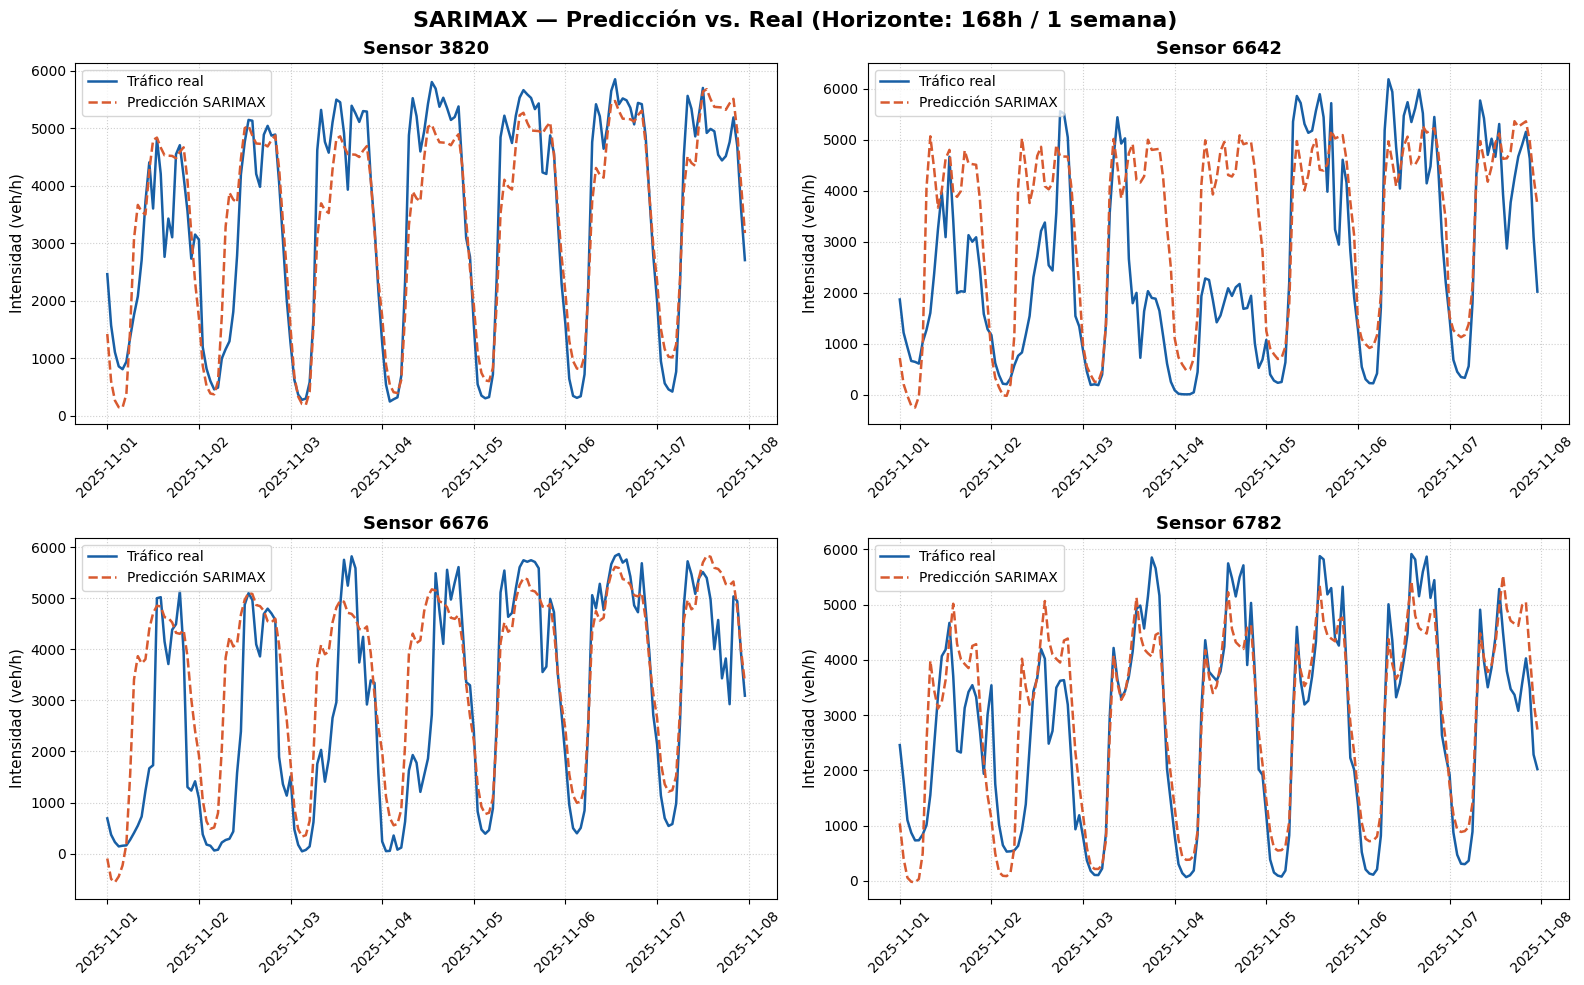

In [7]:
import matplotlib.pyplot as plt

plt.style.use('default')
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
fig.suptitle('SARIMAX — Predicción vs. Real (Horizonte: 168h / 1 semana)',
             fontsize=16, fontweight='bold', y=0.98)
axes = axes.flatten()

for i, col in enumerate(cols_intensidad):
    ax = axes[i]
    sensor_id = col.split('_')[-1]

    real_data = val_df[col].iloc[:168]
    pred_data = df_pred_168h[col]

    ax.plot(real_data.index, real_data.values,
            label='Tráfico real', color='#185FA5', linewidth=1.8)
    ax.plot(pred_data.index, pred_data.values,
            label='Predicción SARIMAX', color='#D85A30',
            linestyle='--', linewidth=1.8)

    ax.set_title(f'Sensor {sensor_id}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Intensidad (veh/h)', fontsize=11)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(fontsize=10)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('grafico_sarimax_168h.png', dpi=300, bbox_inches='tight')
print("✅ Gráfico guardado: 'grafico_sarimax_168h.png'")
plt.show()

## Paso 7: Evaluación final sobre Test
Una vez validados los hiperparámetros, se evalúa el modelo sobre el conjunto de test (datos no vistos).

In [8]:
print("--- EVALUACIÓN FINAL SOBRE TEST (datos no vistos) ---")

df_pred_test_1h   = predecir_horizonte(modelos_sarimax, test_df, cols_exogenas, steps=1)
df_pred_test_24h  = predecir_horizonte(modelos_sarimax, test_df, cols_exogenas, steps=24)
df_pred_test_168h = predecir_horizonte(modelos_sarimax, test_df, cols_exogenas, steps=168)

print("\n========================================")
print("   RESULTADOS SARIMAX — TEST FINAL")
print("========================================")
evaluar_predicciones(test_df, df_pred_test_1h,   cols_intensidad, " 1 HORA   (corto plazo)")
evaluar_predicciones(test_df, df_pred_test_24h,  cols_intensidad, "24 HORAS  (medio plazo)")
evaluar_predicciones(test_df, df_pred_test_168h, cols_intensidad, "168 HORAS (largo plazo / 1 semana)")

--- EVALUACIÓN FINAL SOBRE TEST (datos no vistos) ---

   RESULTADOS SARIMAX — TEST FINAL

[ HORIZONTE:  1 HORA   (corto plazo) ]
  Sensor 3820  →  RMSE:   772.41 veh/h  |  R²:     nan
  Sensor 6642  →  RMSE:    14.09 veh/h  |  R²:     nan
  Sensor 6676  →  RMSE:  1088.69 veh/h  |  R²:     nan
  Sensor 6782  →  RMSE:   711.62 veh/h  |  R²:     nan
  ────────────────────────────────────────────────────
  PROMEDIO GLOBAL   →  RMSE:   646.70 veh/h  |  R²:     nan

[ HORIZONTE: 24 HORAS  (medio plazo) ]
  Sensor 3820  →  RMSE:  1886.05 veh/h  |  R²: -1.0919
  Sensor 6642  →  RMSE:  2128.71 veh/h  |  R²: -1.2505
  Sensor 6676  →  RMSE:  2065.94 veh/h  |  R²: -1.9225
  Sensor 6782  →  RMSE:  1953.91 veh/h  |  R²: -2.8388
  ────────────────────────────────────────────────────
  PROMEDIO GLOBAL   →  RMSE:  2008.65 veh/h  |  R²: -1.7759

[ HORIZONTE: 168 HORAS (largo plazo / 1 semana) ]
  Sensor 3820  →  RMSE:  1005.71 veh/h  |  R²:  0.6548
  Sensor 6642  →  RMSE:  1369.40 veh/h  |  R²:  0.4834

(1165.3858685368375, 0.49811766935343293)